### Importaciones de librerias.
- La libreria SQLite3 para la conexion a nuestra base de datos.
- La libreria pandas para el manejo de los datos.
- La libreria numpy para el manejo de elementos numericos.
- La libreria matplotlib y seaborn para la graficacion de los datos.
- La libreria scikit-learn para el uso y entrenamiento de modelos de machine learning
- Tambien se instalo el plugin wrangler que facilitara la visualizacion de los datos para un mejor analisis de los mismos.

In [ ]:
import sqlite3

import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

### Conexion a la base de datos.

In [2]:
# Conexion a la base de datos.
conn = sqlite3.connect('database.sqlite')
query = "SELECT * FROM sqlite_master WHERE type = 'table';"

### Generar Data Frames

>Generar data frames a partir de las tablas existentes en la base de datos para realizar un analisis preliminar de los datos.

In [3]:
# Obtener todos los nombres de las tabas en la base de datos
tables = pd.read_sql_query(query, conn)['name'].tolist()

# Diccionario para almacernar todas las tablas en un dataframe.
df = {}

# Cargar cada tabla en un dataframe.
for table in tables:
    query = f"SELECT * FROM {table};"
    df[table] = pd.read_sql_query(query, conn)

# Cerrar la conexion a la base de datos.
conn.close()

# Mostrar los nombres de las tablas.
df.keys()


dict_keys(['sqlite_sequence', 'Player_Attributes', 'Player', 'Match', 'League', 'Country', 'Team', 'Team_Attributes'])

### Analisis Exploratorio de Datos (EDA)
> Exploracion de los datos: explorar la estructura del dataset para identificar tipos de datos y valores nulos.

In [4]:
# Mostrar informacion general sobre la tabla.
df['sqlite_sequence'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    7 non-null      object
 1   seq     7 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 244.0+ bytes


In [5]:
# Mostrar informacion de datos numericos sobre la tabla.
df['sqlite_sequence'].describe()

,seq
count,7.000000
mean,65185.857143
std,62082.942398
min,1458.000000
25%,31516.500000
50%,51958.000000
75%,77937.000000
max,183978.000000


> La tabla "sqlite_sequence" cuenta solamente con 2 columnas y contiene un total de 7 registros completos sin nulos o valores atipicos en sus datos.
- cuenta con una (1) columna tipo string.
- cuenta con una (1) columna tipo entero.

In [6]:
# Mostrar informacion general sobre la tabla.
df['Player_Attributes'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183978 entries, 0 to 183977
Data columns (total 42 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   183978 non-null  int64  
 1   player_fifa_api_id   183978 non-null  int64  
 2   player_api_id        183978 non-null  int64  
 3   date                 183978 non-null  object 
 4   overall_rating       183142 non-null  float64
 5   potential            183142 non-null  float64
 6   preferred_foot       183142 non-null  object 
 7   attacking_work_rate  180748 non-null  object 
 8   defensive_work_rate  183142 non-null  object 
 9   crossing             183142 non-null  float64
 10  finishing            183142 non-null  float64
 11  heading_accuracy     183142 non-null  float64
 12  short_passing        183142 non-null  float64
 13  volleys              181265 non-null  float64
 14  dribbling            183142 non-null  float64
 15  curve            

In [7]:
# Mostrar informacion de datos numericos sobre la tabla.
df['Player_Attributes'].describe()

,id,player_fifa_api_id,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,183978.00000,183978.000000,183978.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,...,181265.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000
mean,91989.50000,165671.524291,135900.617324,68.600015,73.460353,55.086883,49.921078,57.266023,62.429672,49.468436,...,57.873550,55.003986,46.772242,50.351257,48.001462,14.704393,16.063612,20.998362,16.132154,16.441439
std,53110.01825,53851.094769,136927.840510,7.041139,6.592271,17.242135,19.038705,16.488905,14.194068,18.256618,...,15.144086,15.546519,21.227667,21.483706,21.598778,16.865467,15.867382,21.452980,16.099175,17.198155
min,1.00000,2.000000,2625.000000,33.000000,39.000000,1.000000,1.000000,1.000000,3.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,45995.25000,155798.000000,34763.000000,64.000000,69.000000,45.000000,34.000000,49.000000,57.000000,35.000000,...,49.000000,45.000000,25.000000,29.000000,25.000000,7.000000,8.000000,8.000000,8.000000,8.000000
50%,91989.50000,183488.000000,77741.000000,69.000000,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,...,60.000000,57.000000,50.000000,56.000000,53.000000,10.000000,11.000000,12.000000,11.000000,11.000000
75%,137983.75000,199848.000000,191080.000000,73.000000,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,...,69.000000,67.000000,66.000000,69.000000,67.000000,13.000000,15.000000,15.000000,15.000000,15.000000
max,183978.00000,234141.000000,750584.000000,94.000000,97.000000,95.000000,97.000000,98.000000,97.000000,93.000000,...,97.000000,96.000000,96.000000,95.000000,95.000000,94.000000,93.000000,97.000000,96.000000,96.000000


In [8]:
df['Player_Attributes'].isnull().sum().sort_values()

id                        0
player_fifa_api_id        0
player_api_id             0
date                      0
overall_rating          836
potential               836
preferred_foot          836
defensive_work_rate     836
short_passing           836
crossing                836
finishing               836
heading_accuracy        836
dribbling               836
ball_control            836
long_passing            836
free_kick_accuracy      836
interceptions           836
aggression              836
strength                836
acceleration            836
sprint_speed            836
reactions               836
stamina                 836
shot_power              836
positioning             836
long_shots              836
gk_handling             836
gk_kicking              836
gk_diving               836
standing_tackle         836
marking                 836
penalties               836
gk_reflexes             836
gk_positioning          836
sliding_tackle         2713
jumping             

> La tabla "Player_Attributes" cuenta con 42 columnas y 183978 registros en su totalidad, sin embargo se pueden observar diversos valores nulos en diferentes columnas, la columna que contiene fechas esta como texto, se evaluara como proceder con su tratamiento de los datos faltantes y la columna fechas.

- cuenta con treinta y cinco (35) columnas tipo Flotantes.
- cuenta con tres (3) columnas tipo entero.
- cuenta con cuatro (4) columnas tipo texto.

In [9]:
# Mostrar informacion general sobre la tabla.
df['Player'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11060 entries, 0 to 11059
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  11060 non-null  int64  
 1   player_api_id       11060 non-null  int64  
 2   player_name         11060 non-null  object 
 3   player_fifa_api_id  11060 non-null  int64  
 4   birthday            11060 non-null  object 
 5   height              11060 non-null  float64
 6   weight              11060 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 605.0+ KB


In [10]:
# Mostrar informacion de datos numericos sobre la tabla.
df['Player'].describe()

,id,player_api_id,player_fifa_api_id,height,weight
count,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000
mean,5537.511392,156582.427215,165664.910488,181.867445,168.380289
std,3197.692647,160713.700624,58649.928360,6.369201,14.990217
min,1.000000,2625.000000,2.000000,157.480000,117.000000
25%,2767.750000,35555.500000,151889.500000,177.800000,159.000000
50%,5536.500000,96619.500000,184671.000000,182.880000,168.000000
75%,8306.250000,212470.500000,203883.250000,185.420000,179.000000
max,11075.000000,750584.000000,234141.000000,208.280000,243.000000


In [11]:
df['Player'].isnull().sum().sort_values()

id                    0
player_api_id         0
player_name           0
player_fifa_api_id    0
birthday              0
height                0
weight                0
dtype: int64

> La tabla "Player" cuenta con 7 columnas y 11060 registros registros completos sin nulos.

- cuenta con una (1) columna tipo Flotante.
- cuenta con  cuatro (4) columnas tipo entero.
- cuenta con dos (2) columnas tipo texto.

In [12]:
# Mostrar informacion general sobre la tabla.
df['Match'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Columns: 115 entries, id to BSA
dtypes: float64(96), int64(9), object(10)
memory usage: 22.8+ MB


In [13]:
# Mostrar informacion de datos numericos sobre la tabla.
df['Match'].describe()

,id,country_id,league_id,stage,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
count,25979.000000,25979.000000,25979.000000,25979.000000,2.597900e+04,25979.000000,25979.000000,25979.000000,25979.000000,24158.000000,...,17097.000000,22568.000000,22568.000000,22568.000000,14162.000000,14162.000000,14162.000000,14161.000000,14161.000000,14161.000000
mean,12990.000000,11738.630317,11738.630317,18.242773,1.195429e+06,9984.371993,9984.475115,1.544594,1.160938,0.999586,...,4.622343,2.668107,3.899048,4.840281,2.498764,3.648189,4.353097,2.497894,3.660742,4.405663
std,7499.635658,7553.936759,7553.936759,10.407354,4.946279e+05,14087.453758,14087.445135,1.297158,1.142110,0.022284,...,3.632164,1.928753,1.248221,4.318338,1.489299,0.867440,3.010189,1.507793,0.868272,3.189814
min,1.000000,1.000000,1.000000,1.000000,4.831290e+05,1601.000000,1601.000000,0.000000,0.000000,0.000000,...,1.100000,1.030000,1.620000,1.080000,1.050000,1.450000,1.120000,1.040000,1.330000,1.120000
25%,6495.500000,4769.000000,4769.000000,9.000000,7.684365e+05,8475.000000,8475.000000,1.000000,0.000000,1.000000,...,2.500000,1.700000,3.300000,2.550000,1.670000,3.200000,2.500000,1.670000,3.250000,2.500000
50%,12990.000000,10257.000000,10257.000000,18.000000,1.147511e+06,8697.000000,8697.000000,1.000000,1.000000,1.000000,...,3.500000,2.150000,3.500000,3.500000,2.100000,3.300000,3.400000,2.100000,3.400000,3.400000
75%,19484.500000,17642.000000,17642.000000,27.000000,1.709852e+06,9925.000000,9925.000000,2.000000,2.000000,1.000000,...,5.250000,2.800000,4.000000,5.400000,2.650000,3.750000,5.000000,2.620000,3.750000,5.000000
max,25979.000000,24558.000000,24558.000000,38.000000,2.216672e+06,274581.000000,274581.000000,10.000000,9.000000,2.000000,...,41.000000,36.000000,26.000000,67.000000,21.000000,11.000000,34.000000,17.000000,13.000000,34.000000


In [14]:
df['Match'].isnull().sum().sort_values()

id                0
country_id        0
league_id         0
season            0
stage             0
              ...  
BSD           11818
BSH           11818
PSH           14811
PSA           14811
PSD           14811
Length: 115, dtype: int64

> La tabla "Match" cuenta con 115 columnas y 25979 registros en su totalidad, sin embargo se pueden observar diversos valores nulos en diferentes columnas, existen dos columnas que contienen fechas y se encuentran en formato de tipo texto, tambien se observario registros atipicos 8 de las columnas, se evaluara como proceder con su tratamiento de los datos faltantes, valores atipicos y columnas fechas.


- cuenta con noventa y seis (96) columna tipo Flotante.
- cuenta con  nueve (9) columnas tipo entero.
- cuenta con diez (10) columnas tipo texto.

In [15]:
# Mostrar informacion general sobre la tabla.
df['League'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          11 non-null     int64 
 1   country_id  11 non-null     int64 
 2   name        11 non-null     object
dtypes: int64(2), object(1)
memory usage: 396.0+ bytes


In [16]:
# Mostrar informacion de datos numericos sobre la tabla.
df['League'].describe()

,id,country_id
count,11.000000,11.000000
mean,12452.090909,12452.090909
std,8215.308472,8215.308472
min,1.000000,1.000000
25%,6289.000000,6289.000000
50%,13274.000000,13274.000000
75%,18668.000000,18668.000000
max,24558.000000,24558.000000


In [17]:
df['League'].isnull().sum().sort_values()

id            0
country_id    0
name          0
dtype: int64

> La tabla "League" cuenta con 3 columnas y 11 registros en su totalidad, sin nulos.



- cuenta con  dos (2) columnas tipo entero.
- cuenta con una (1) columna tipo texto.

In [18]:
# Mostrar informacion general sobre la tabla.
df['Country'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      11 non-null     int64 
 1   name    11 non-null     object
dtypes: int64(1), object(1)
memory usage: 308.0+ bytes


In [19]:
# Mostrar informacion de datos numericos sobre la tabla.
df['Country'].describe()

,id
count,11.000000
mean,12452.090909
std,8215.308472
min,1.000000
25%,6289.000000
50%,13274.000000
75%,18668.000000
max,24558.000000


In [20]:
df['Country'].isnull().sum().sort_values()

id      0
name    0
dtype: int64

> La tabla "Country" cuenta solamente con 2 columnas y contiene un total de 11 registros completos sin nulos o valores atipicos en sus datos.
- cuenta con una (1) columna tipo string.
- cuenta con una (1) columna tipo entero.

In [21]:
# Mostrar informacion general sobre la tabla.
df['Team'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                299 non-null    int64  
 1   team_api_id       299 non-null    int64  
 2   team_fifa_api_id  288 non-null    float64
 3   team_long_name    299 non-null    object 
 4   team_short_name   299 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.8+ KB


In [22]:
# Mostrar informacion de datos numericos sobre la tabla.
df['Team'].describe()

,id,team_api_id,team_fifa_api_id
count,299.000000,299.000000,288.000000
mean,23735.301003,12340.521739,21534.305556
std,15167.914719,25940.411135,42456.439408
min,1.000000,1601.000000,1.000000
25%,9552.500000,8349.000000,178.750000
50%,22805.000000,8655.000000,673.500000
75%,36250.500000,9886.500000,1910.750000
max,51606.000000,274581.000000,112513.000000


In [23]:
df['Team'].isnull().sum().sort_values()

id                   0
team_api_id          0
team_long_name       0
team_short_name      0
team_fifa_api_id    11
dtype: int64

> La tabla "Team" cuenta solamente con 5 columnas y contiene un total de 299 registros, tiene pocos valores nulos y sin valores atipicos en sus datos.
- cuenta con dos (2) columnas tipo string.
- cuenta con dos (2) columnas tipo entero.
- cuenta con una (1) columna tipo Flotante.

In [24]:
# Mostrar informacion general sobre la tabla.
df['Team_Attributes'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1458 non-null   int64  
 1   team_fifa_api_id                1458 non-null   int64  
 2   team_api_id                     1458 non-null   int64  
 3   date                            1458 non-null   object 
 4   buildUpPlaySpeed                1458 non-null   int64  
 5   buildUpPlaySpeedClass           1458 non-null   object 
 6   buildUpPlayDribbling            489 non-null    float64
 7   buildUpPlayDribblingClass       1458 non-null   object 
 8   buildUpPlayPassing              1458 non-null   int64  
 9   buildUpPlayPassingClass         1458 non-null   object 
 10  buildUpPlayPositioningClass     1458 non-null   object 
 11  chanceCreationPassing           1458 non-null   int64  
 12  chanceCreationPassingClass      14

In [25]:
# Mostrar informacion de datos numericos sobre la tabla.
df['Team_Attributes'].describe()

,id,team_fifa_api_id,team_api_id,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
count,1458.000000,1458.000000,1458.000000,1458.000000,489.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,729.500000,17706.982167,9995.727023,52.462277,48.607362,48.490398,52.165295,53.731824,53.969136,46.017147,49.251029,52.185871
std,421.032659,39179.857739,13264.869900,11.545869,9.678290,10.896101,10.360793,11.086796,10.327566,10.227225,9.738028,9.574712
min,1.000000,1.000000,1601.000000,20.000000,24.000000,20.000000,21.000000,20.000000,22.000000,23.000000,24.000000,29.000000
25%,365.250000,110.000000,8457.750000,45.000000,42.000000,40.000000,46.000000,47.000000,48.000000,39.000000,44.000000,47.000000
50%,729.500000,485.000000,8674.000000,52.000000,49.000000,50.000000,52.000000,53.000000,53.000000,45.000000,48.000000,52.000000
75%,1093.750000,1900.000000,9904.000000,62.000000,55.000000,55.000000,59.000000,62.000000,61.000000,51.000000,55.000000,58.000000
max,1458.000000,112513.000000,274581.000000,80.000000,77.000000,80.000000,80.000000,80.000000,80.000000,72.000000,72.000000,73.000000


In [26]:
df['Team_Attributes'].isnull().sum().sort_values()

id                                  0
team_fifa_api_id                    0
team_api_id                         0
date                                0
buildUpPlaySpeed                    0
buildUpPlaySpeedClass               0
buildUpPlayDribblingClass           0
buildUpPlayPassing                  0
chanceCreationPassingClass          0
buildUpPlayPassingClass             0
buildUpPlayPositioningClass         0
chanceCreationPassing               0
chanceCreationCrossingClass         0
chanceCreationCrossing              0
chanceCreationShooting              0
chanceCreationShootingClass         0
defenceDefenderLineClass            0
chanceCreationPositioningClass      0
defencePressure                     0
defencePressureClass                0
defenceAggression                   0
defenceAggressionClass              0
defenceTeamWidth                    0
defenceTeamWidthClass               0
buildUpPlayDribbling              969
dtype: int64

> La tabla "Team_Attributes" cuenta con 25 columnas y 1458 registros en su totalidad, sin embargo se pueden observar diversos valores nulos en diferentes columnas, se evaluara como proceder con su tratamiento de los datos faltantes, valores atipicos y columnas fechas.


- cuenta con una (1) columna tipo Flotante.
- cuenta con  once (11) columnas tipo entero.
- cuenta con trece (13) columnas tipo texto.

## Transformacion y carga de los datos para disponibilizarlos ETL

In [27]:
# Nombre de columna a tratar.
column = 'defensive_work_rate'

# Mostrar los registros que contengan valores nulos en la tabla.
df_null = df['Player_Attributes'][df['Player_Attributes'].isnull().any(axis=1)]
df_null

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
373,374,156626,46447,2010-08-30 00:00:00,64.0,71.0,right,None,_0,41.0,...,61.0,39.0,62.0,61.0,57.0,15.0,14.0,13.0,10.0,12.0
374,375,156626,46447,2010-02-22 00:00:00,64.0,71.0,right,None,_0,41.0,...,61.0,58.0,62.0,61.0,57.0,6.0,20.0,45.0,20.0,20.0
375,376,156626,46447,2008-08-30 00:00:00,66.0,71.0,right,None,_0,41.0,...,61.0,58.0,67.0,61.0,57.0,6.0,20.0,45.0,20.0,20.0
376,377,156626,46447,2007-08-30 00:00:00,68.0,75.0,right,None,_0,41.0,...,61.0,58.0,69.0,64.0,57.0,6.0,20.0,45.0,20.0,20.0
377,378,156626,46447,2007-02-22 00:00:00,66.0,65.0,right,None,_0,41.0,...,61.0,55.0,66.0,63.0,57.0,6.0,9.0,45.0,13.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183963,183964,47058,35506,2009-08-30 00:00:00,70.0,78.0,right,None,_0,48.0,...,63.0,70.0,70.0,74.0,65.0,14.0,25.0,51.0,25.0,25.0
183964,183965,47058,35506,2009-02-22 00:00:00,70.0,78.0,right,None,_0,48.0,...,63.0,70.0,70.0,74.0,65.0,14.0,25.0,51.0,25.0,25.0
183965,183966,47058,35506,2008-08-30 00:00:00,72.0,78.0,right,None,_0,48.0,...,63.0,70.0,76.0,78.0,65.0,14.0,25.0,51.0,25.0,25.0
183966,183967,47058,35506,2007-08-30 00:00:00,75.0,78.0,right,None,_0,48.0,...,63.0,70.0,76.0,78.0,65.0,14.0,25.0,51.0,25.0,25.0


In [28]:
# Mostrar los valores unicos en la columna.
df['Player_Attributes'][column].unique()

array(['medium', 'high', 'low', '_0', None, '5', 'ean', 'o', '1', 'ormal',
       '7', '2', '8', '4', 'tocky', '0', '3', '6', '9', 'es'],
      dtype=object)

In [29]:
df['Player_Attributes']

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,183974,102359,39902,2009-08-30 00:00:00,83.0,85.0,right,medium,low,84.0,...,88.0,83.0,22.0,31.0,30.0,9.0,20.0,84.0,20.0,20.0
183974,183975,102359,39902,2009-02-22 00:00:00,78.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183975,183976,102359,39902,2008-08-30 00:00:00,77.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183976,183977,102359,39902,2007-08-30 00:00:00,78.0,81.0,right,medium,low,74.0,...,88.0,53.0,28.0,32.0,30.0,9.0,20.0,73.0,20.0,20.0


In [30]:
# Evaluar la moda de la columna tratada.
mode_value = df['Player_Attributes'][column].mode()[0]

# Valores a Reemplazar.
replaces = {
    "0":"low","_0":"low", "o":"low","1":"low","2":"low","3":"low",
            "4":"medium","5":"medium","6":"medium",
            "7":"medium","8":"high","9":"high", 
            "ormal":f"{mode_value}", "ean":f"{mode_value}","tocky": f"{mode_value}", 
            "es":f"{mode_value}"
            }

# Reemplazar valores nulos por la moda.
df['Player_Attributes'][column] = df['Player_Attributes'][column].fillna(mode_value)
# Reemplazar valores numericos por low, medium y high.
df['Player_Attributes'][column] = df['Player_Attributes'][column].replace(replaces) 

df['Player_Attributes']



,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,183974,102359,39902,2009-08-30 00:00:00,83.0,85.0,right,medium,low,84.0,...,88.0,83.0,22.0,31.0,30.0,9.0,20.0,84.0,20.0,20.0
183974,183975,102359,39902,2009-02-22 00:00:00,78.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183975,183976,102359,39902,2008-08-30 00:00:00,77.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183976,183977,102359,39902,2007-08-30 00:00:00,78.0,81.0,right,medium,low,74.0,...,88.0,53.0,28.0,32.0,30.0,9.0,20.0,73.0,20.0,20.0


In [31]:
# Verificar los valores unicos.
df['Player_Attributes'][column].unique()

array(['medium', 'high', 'low'], dtype=object)

#### Columma attacking_work_rate

In [32]:
# Evaluar los elementos unicos.
column = 'attacking_work_rate'
df['Player_Attributes'][column].unique()


array(['medium', 'high', None, 'low', 'None', 'le', 'norm', 'stoc', 'y'],
      dtype=object)

In [33]:
# Evaluar la moda de la columna tratada.
mode_value = df['Player_Attributes'][column].mode()[0]

# Valores a Reemplazar.
replaces = {
            "stoc":f"{mode_value}", "y":f"{mode_value}",
            None:f"{mode_value}", "None":f"{mode_value}","le": f"{mode_value}", 
            "norm":f"{mode_value}"
            }

# Reemplazar valores nulos por la moda.
df['Player_Attributes'][column] = df['Player_Attributes'][column].fillna(mode_value)
# Reemplazar valores numericos por low, medium y high.
df['Player_Attributes'][column] = df['Player_Attributes'][column].replace(replaces) 

df['Player_Attributes']

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,183974,102359,39902,2009-08-30 00:00:00,83.0,85.0,right,medium,low,84.0,...,88.0,83.0,22.0,31.0,30.0,9.0,20.0,84.0,20.0,20.0
183974,183975,102359,39902,2009-02-22 00:00:00,78.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183975,183976,102359,39902,2008-08-30 00:00:00,77.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183976,183977,102359,39902,2007-08-30 00:00:00,78.0,81.0,right,medium,low,74.0,...,88.0,53.0,28.0,32.0,30.0,9.0,20.0,73.0,20.0,20.0


#### Columna preferred_foot

In [34]:
column = 'preferred_foot'
df['Player_Attributes'][column].unique()


array(['right', 'left', None], dtype=object)

In [35]:
# Evaluar la moda de la columna tratada.
mode_value = df['Player_Attributes'][column].mode()[0]

# Valores a Reemplazar.
replaces = {None:f"{mode_value}"}

# Reemplazar valores nulos por la moda.
df['Player_Attributes'][column] = df['Player_Attributes'][column].fillna(mode_value)
# Reemplazar valores numericos por low, medium y high.
df['Player_Attributes'][column] = df['Player_Attributes'][column].replace(replaces) 

df['Player_Attributes']

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,183974,102359,39902,2009-08-30 00:00:00,83.0,85.0,right,medium,low,84.0,...,88.0,83.0,22.0,31.0,30.0,9.0,20.0,84.0,20.0,20.0
183974,183975,102359,39902,2009-02-22 00:00:00,78.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183975,183976,102359,39902,2008-08-30 00:00:00,77.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183976,183977,102359,39902,2007-08-30 00:00:00,78.0,81.0,right,medium,low,74.0,...,88.0,53.0,28.0,32.0,30.0,9.0,20.0,73.0,20.0,20.0


### Llenar los valores nulos de las columnas numericas con la moda.


In [36]:
# Crear lista con las columnas numericas para iterar-
numeric_columns = df['Player_Attributes'].select_dtypes(include=['number']).columns
numeric_columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'overall_rating',
       'potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='object')

In [37]:
for column in numeric_columns:
    # Obtener la moda de la columna.
    mode_value = df['Player_Attributes'][column].mode()[0]

    # Reemplazar los valores con la moda.
    df['Player_Attributes'][column] = df['Player_Attributes'][column].fillna(mode_value)

df['Player_Attributes']


,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,183974,102359,39902,2009-08-30 00:00:00,83.0,85.0,right,medium,low,84.0,...,88.0,83.0,22.0,31.0,30.0,9.0,20.0,84.0,20.0,20.0
183974,183975,102359,39902,2009-02-22 00:00:00,78.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183975,183976,102359,39902,2008-08-30 00:00:00,77.0,80.0,right,medium,low,74.0,...,88.0,70.0,32.0,31.0,30.0,9.0,20.0,73.0,20.0,20.0
183976,183977,102359,39902,2007-08-30 00:00:00,78.0,81.0,right,medium,low,74.0,...,88.0,53.0,28.0,32.0,30.0,9.0,20.0,73.0,20.0,20.0


In [38]:
# Convertir los datos de la columna 'date' en tipo datetime para mejorar el analisis de los datos
df['Player_Attributes']['date'] = pd.to_datetime(df['Player_Attributes']['date'], errors='coerce')
df['Player_Attributes']['date'].head()


0   2016-02-18
1   2015-11-19
2   2015-09-21
3   2015-03-20
4   2007-02-22
Name: date, dtype: datetime64[ns]

### Consideraciones:
> Se decide dejar rellenar los valores nulos en lugar de reemplazarlos ya que cada valor representa un jugador unico y se de eliminar los valores nulos se estaria perdiendo la informacion general de ese jugador en particular, por esa razon se conservan dejando en los valores con texto con la moda de los valores totales en cada columna.

## Tranformacion de la tabla Tabla Match

In [39]:
df['Match']

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25974,25975,24558,24558,2015/2016,9,2015-09-22 00:00:00,1992091,10190,10191,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25975,25976,24558,24558,2015/2016,9,2015-09-23 00:00:00,1992092,9824,10199,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25976,25977,24558,24558,2015/2016,9,2015-09-23 00:00:00,1992093,9956,10179,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25977,25978,24558,24558,2015/2016,9,2015-09-22 00:00:00,1992094,7896,10243,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Columnas a eliminar.
colums = ['goal', 'shoton', 'shotoff', 'foulcommit', 'card',
       'cross', 'corner', 'possession']

# Eliminar columnas que no aportan informacion relevante o contienen valores nulos o no validos.
df['Match'] = df['Match'].drop(columns = colums, axis=1) 
df['Match'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Columns: 107 entries, id to BSA
dtypes: float64(96), int64(9), object(2)
memory usage: 21.2+ MB


In [41]:
# Llenar los valores nulos de la tabla 'Macth' con 0
df['Match'] = df['Match'].fillna(0)
df['Match']

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25974,25975,24558,24558,2015/2016,9,2015-09-22 00:00:00,1992091,10190,10191,1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25975,25976,24558,24558,2015/2016,9,2015-09-23 00:00:00,1992092,9824,10199,1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25976,25977,24558,24558,2015/2016,9,2015-09-23 00:00:00,1992093,9956,10179,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25977,25978,24558,24558,2015/2016,9,2015-09-22 00:00:00,1992094,7896,10243,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
# Convertir los datos de la columna a tipo 'datetime'.
df['Match']['date'] = pd.to_datetime(df['Match']['date'], errors='coerce')


# Separar los años y crear columnas auxiliares para crear el rango de fechas.
df['Match'][['start_year', 'end_year']] = df['Match']['season'].str.split('/', expand=True)

# Convertir a fechas
df['Match']['start_date'] = pd.to_datetime(df['Match']['start_year'] + '-08-01')
df['Match']['end_date'] = pd.to_datetime(df['Match']['end_year'] + '-06-30')

# Crear un rango de fechas para reemplazar el texto en la columna 'season'.
df['Match']['season'] = df['Match'].apply(lambda x: pd.Interval(x['start_date'], x['end_date'], closed='both'), axis=1)

# Eliminar columnas auxiliares.
df['Match'].drop(columns=['start_year', 'end_year', 'start_date', 'end_date'], inplace=True)


In [43]:
df['Match']

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,"[2008-08-01 00:00:00, 2009-06-30 00:00:00]",1,2008-08-17,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,"[2008-08-01 00:00:00, 2009-06-30 00:00:00]",1,2008-08-16,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,"[2008-08-01 00:00:00, 2009-06-30 00:00:00]",1,2008-08-16,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,"[2008-08-01 00:00:00, 2009-06-30 00:00:00]",1,2008-08-17,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,"[2008-08-01 00:00:00, 2009-06-30 00:00:00]",1,2008-08-16,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25974,25975,24558,24558,"[2015-08-01 00:00:00, 2016-06-30 00:00:00]",9,2015-09-22,1992091,10190,10191,1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25975,25976,24558,24558,"[2015-08-01 00:00:00, 2016-06-30 00:00:00]",9,2015-09-23,1992092,9824,10199,1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25976,25977,24558,24558,"[2015-08-01 00:00:00, 2016-06-30 00:00:00]",9,2015-09-23,1992093,9956,10179,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25977,25978,24558,24558,"[2015-08-01 00:00:00, 2016-06-30 00:00:00]",9,2015-09-22,1992094,7896,10243,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### Consideraciones.
- Se eliminaro las columnas que no representaban un valor agregado a la informacion, en esta caso por informacion no valida y registros nulos, se contaban con 8 columnas con estas caracteristicas ()
- Debido a la cantidad de nulos y al no contar con la descripcion de las tablas y las columnas de decicio no eliminar filas ya que la cantidad de nulos reduce significativamente el set de datos, por ende se decidio reemplazar los valores nulos por 0 con la consideracion de evaluar de manera independiente cada columna para determinar su relevancia y decidir si conservar o no los datos (existian columnas con mas de 47% de datos nulos).
- Se cambio el formato de las columnas de tipo texto por tipo fecha correspondiente.
- para la columna season se ha creado un rango de fechas para las temporadas en formato de fecha respectivamente.


## Transformacion de la tabla Team

In [44]:
df['Team']

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB
...,...,...,...,...,...
294,49479,10190,898.0,FC St. Gallen,GAL
295,49837,10191,1715.0,FC Thun,THU
296,50201,9777,324.0,Servette FC,SER
297,50204,7730,1862.0,FC Lausanne-Sports,LAU


In [45]:
# columna a eliminar
columns = ['team_fifa_api_id']

df['Team'] = df['Team'].drop(columns=columns, axis=1)
df['Team']

,id,team_api_id,team_long_name,team_short_name
0,1,9987,KRC Genk,GEN
1,2,9993,Beerschot AC,BAC
2,3,10000,SV Zulte-Waregem,ZUL
3,4,9994,Sporting Lokeren,LOK
4,5,9984,KSV Cercle Brugge,CEB
...,...,...,...,...
294,49479,10190,FC St. Gallen,GAL
295,49837,10191,FC Thun,THU
296,50201,9777,Servette FC,SER
297,50204,7730,FC Lausanne-Sports,LAU


### Consideraciones
- solo una columna contenia valores nulos y la misma no aportaba informacion de interes para los datos, por ende se tomo la decision de eliminarla

# Transformacion de tabla Team_Attributes


In [121]:
df['Team_Attributes']

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,...,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,Little,50,Mixed,Organised,...,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,Normal,56,Mixed,Organised,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,Normal,54,Mixed,Organised,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,Little,70,Long,Organised,...,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,Little,52,Mixed,Organised,...,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,1454,15005,10000,2011-02-22 00:00:00,52,Balanced,Little,52,Mixed,Organised,...,53,Normal,Organised,46,Medium,48,Press,53,Normal,Cover
1454,1455,15005,10000,2012-02-22 00:00:00,54,Balanced,Little,51,Mixed,Organised,...,50,Normal,Organised,44,Medium,55,Press,53,Normal,Cover
1455,1456,15005,10000,2013-09-20 00:00:00,54,Balanced,Little,51,Mixed,Organised,...,32,Little,Organised,44,Medium,58,Press,37,Normal,Cover
1456,1457,15005,10000,2014-09-19 00:00:00,54,Balanced,Normal,51,Mixed,Organised,...,32,Little,Organised,44,Medium,58,Press,37,Normal,Cover


In [122]:
# Eliminar la columna buildUpPlayDribbling

columns = ['buildUpPlayDribbling']

df['Team_Attributes'] = df['Team_Attributes'].drop(columns = columns, axis = 1)
df['Team_Attributes']

KeyError: "['buildUpPlayDribbling'] not found in axis"

### Consideraciones
- Se tomo la decision de eliminar la columna buildUpPlayDribbling debido a que arrojaba un indice mayor a 64% en sus valores nulos y evaluando la tabla se pudo contemplar que representaba un rango relacionado con la columna buildUpPlayDribblingClass, en donde los valores faltantes eran menores a un average de 20, que representa el valor de 'little' en la columna buildUpPlayDribblingClass, teniendo esto en cuenta se se puede realizar el analisis con esta columna, eliminando asi los datos nulos y valores redundantes en la tabla.

## Visualizacion de datos

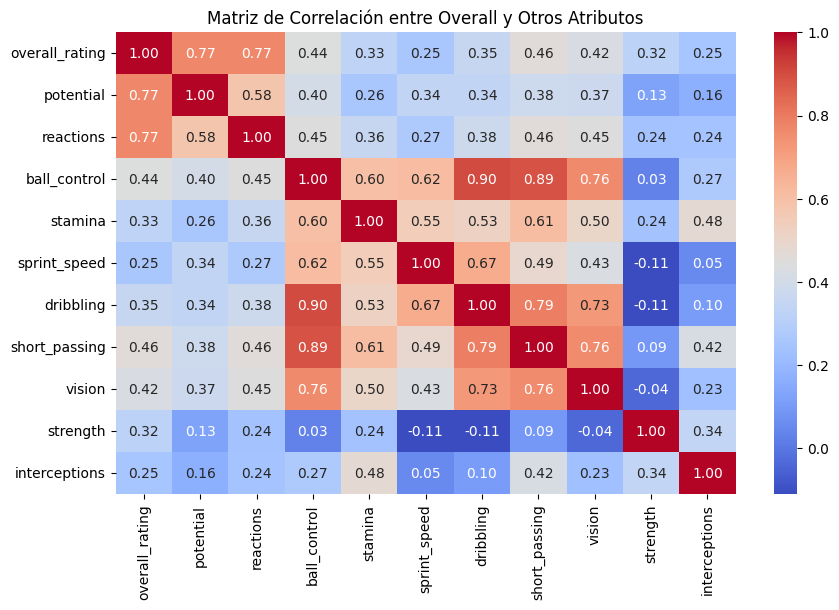

In [ ]:

# Selección de atributos relevantes
attributes = ['overall_rating', 'potential', 'reactions', 'ball_control', 'stamina', 'sprint_speed', 
              'dribbling', 'short_passing', 'vision', 'strength', 'interceptions']

# Matriz de correlación
plt.figure(figsize=(10,6))
sns.heatmap(df['Player_Attributes'][attributes].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación entre Overall y Otros Atributos")
plt.show()

> podemos inferir segun el mapa de calor lo siguiente:
- Las reacciones rapidas son cruciales para el buen desarrollo del jugador.
- El control del balon y el dribbling tienen una alta correlacion positiva tambien, al igual que el con el pase corto, lo que indica que el control de balon por logica tiene tambien buena calidad al regate.
- por otro lado la fuerza y el sprint tienen una correlacion negativa y esto puede indicar como bien sabemos que aquellos con mayor fuerza no suelen ser los mas veloces o agiles.

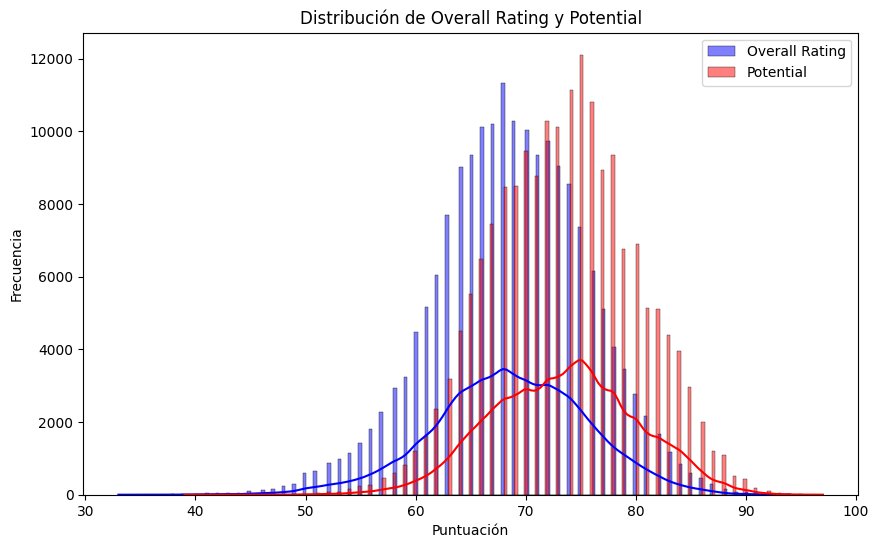

In [ ]:
# Crear grafico de barras.
plt.figure(figsize=(10, 6))
sns.histplot(df['Player_Attributes']['overall_rating'], kde=True, color='blue', label='Overall Rating')
sns.histplot(df['Player_Attributes']['potential'], kde=True, color='red', label='Potential')
plt.title('Distribución de Overall Rating y Potential')
plt.xlabel('Puntuación')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

> En nuestro grafico podemos contemplar una distribucion normal, en los que los valores principales como lo es la media de ovreall se encuentra en 65 y la de potential en 75 se puede decir que la mayoria de los judores tienen un rango de nivel medio al momento de evaluar la excelencia de los mismos.

#### Relacion entre potencial y Overall Rating

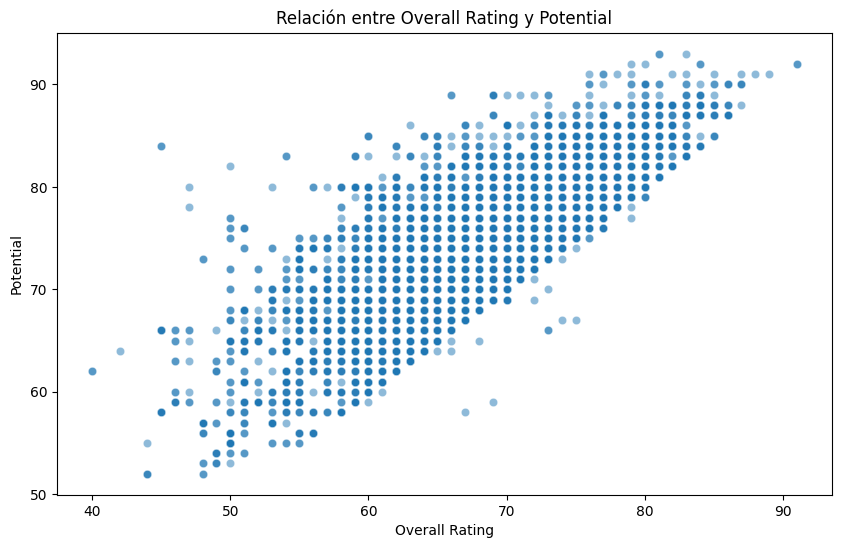

In [ ]:
# Crear grafico de dispersion.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='overall_rating', y='potential', data=df['Player_Attributes'].head(10000), alpha=0.5)
plt.title('Relación entre Overall Rating y Potential')
plt.xlabel('Overall Rating')
plt.ylabel('Potential')
plt.show()

> En la anterior imagen se puede contemplar la correlacion que existe entre el potencia y el Overal, destacando tambien algunos valores fuera del patron que pudiesen ser considerados quiza como jugadores nuevos que se encuentran iniciando su carrera que tienen potencial pero aun no tienen un Overall Rating elevado.

#### Pierna favotita.

C:\Users\Rhamer\AppData\Local\Temp\ipykernel_20340\198327790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='preferred_foot', data=df['Player_Attributes'], palette='Set2')


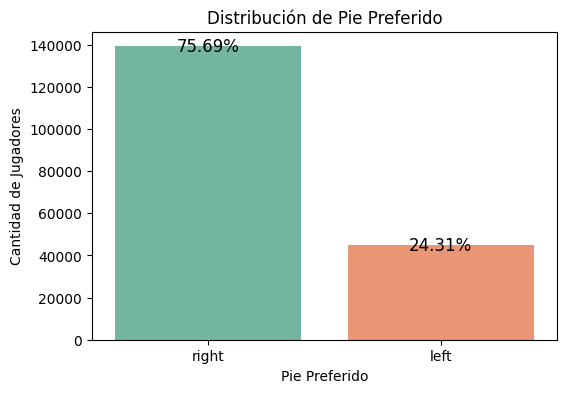

In [ ]:
# Crear el gráfico de barras
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='preferred_foot', data=df['Player_Attributes'], palette='Set2')

# Calcular el total de registros
total = len(df['Player_Attributes'])

# Agregar los porcentajes en cada barra
for p in ax.patches:
    # Calcular el porcentaje
    height = p.get_height()
    percentage = (height / total) * 100
    # Colocar el porcentaje en la parte superior de cada barra
    ax.text(p.get_x() + p.get_width() / 2, height + 50, f'{percentage:.2f}%', 
            ha='center', va='center', fontsize=12)

plt.title('Distribución de Pie Preferido')
plt.xlabel('Pie Preferido')
plt.ylabel('Cantidad de Jugadores')

plt.show()


> En la siguiente imagen podemos contemplar que la mayor concentracion se encuentra en la pierna derecha con un 75% en comparacion con los jugadores que tienden a usar la isquierda como favorita. 

C:\Users\Rhamer\AppData\Local\Temp\ipykernel_20340\33193325.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='preferred_foot', y='overall_rating', data=df['Player_Attributes'], estimator='mean', ci=None, palette='Set2')
C:\Users\Rhamer\AppData\Local\Temp\ipykernel_20340\33193325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='preferred_foot', y='overall_rating', data=df['Player_Attributes'], estimator='mean', ci=None, palette='Set2')


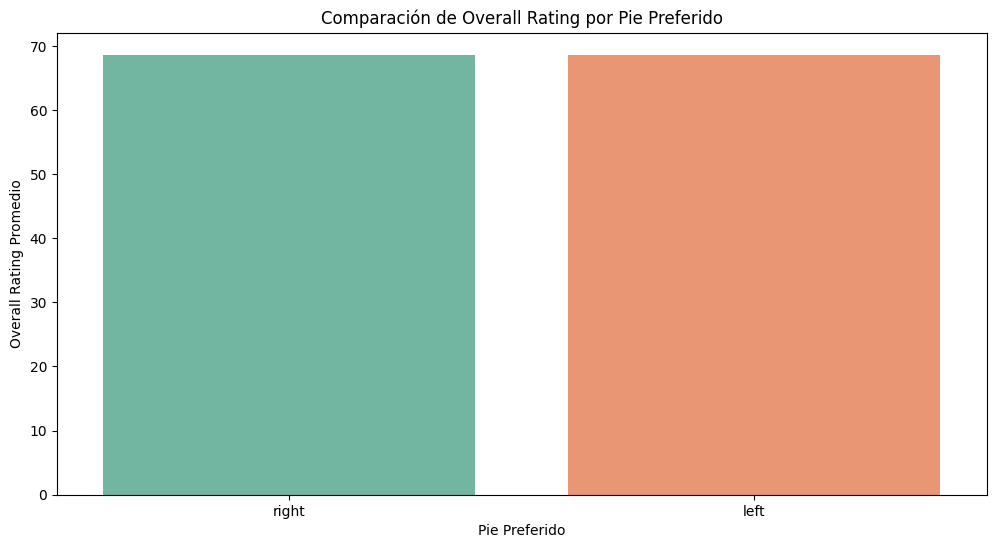

In [ ]:
# Comparar Overall Rating y Potential
plt.figure(figsize=(12, 6))
sns.barplot(x='preferred_foot', y='overall_rating', data=df['Player_Attributes'], estimator='mean', ci=None, palette='Set2')
plt.title('Comparación de Overall Rating por Pie Preferido')
plt.xlabel('Pie Preferido')
plt.ylabel('Overall Rating Promedio')
plt.show()

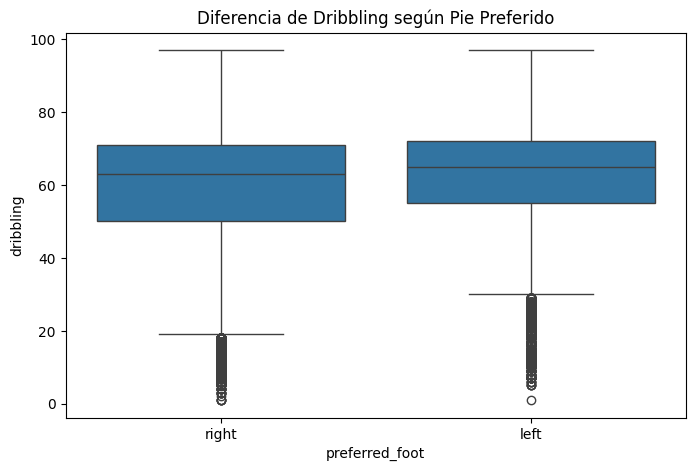

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="preferred_foot", y="dribbling", data=df['Player_Attributes'])
plt.title("Diferencia de Dribbling según Pie Preferido")
plt.show()

> Sin embargo a su vez se puede visualizar que el Overall Rating es el mismo indiferentemente del porcentaje que tengamos con respecto a la pierna favorita del jugado.

### Evolucion del Potencial y el Overall Rating a traves del tiempo.

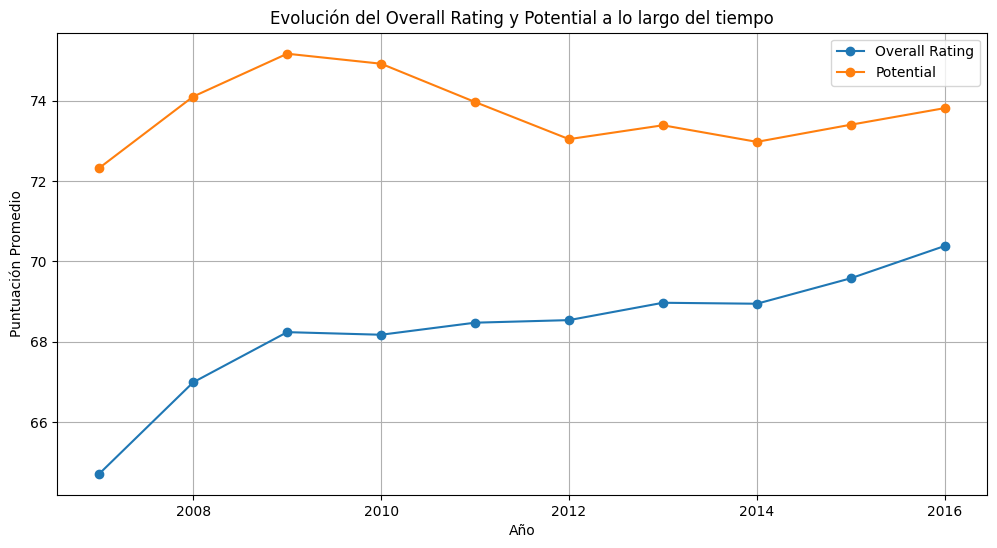

In [ ]:


# Extraer el año de la fecha.
df['Player_Attributes']['year'] = df['Player_Attributes']['date'].dt.year

# Calcular el promedio de overall_rating y potential por año.
yearly_stats = df['Player_Attributes'].groupby('year')[['overall_rating', 'potential']].mean()

# Crear Grafico.
plt.figure(figsize=(12, 6))
yearly_stats['overall_rating'].plot(label='Overall Rating', marker='o')
yearly_stats['potential'].plot(label='Potential', marker='o')
plt.title('Evolución del Overall Rating y Potential a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Puntuación Promedio')
plt.legend()
plt.grid()
plt.show()

> Podemos observar una evolucion positiva previos al 2009 pero, pero en una disminucion en el potencial a partir de ese año, recuperandose y estabilizandose en el 2013, en cuanto al Overall Rating el declive del potencial lo obligo a mantenerse estable con poco nivel de crecimiento a partir del 2009, iniciando una recuperacion significativa solo a partir del año 2013 y 2014.

> Tomando esto en cuenta podriamos destacar las posible promesas de los ultimos 5 años de la siguiente manera.

In [ ]:
# Filtrar los jugadores por los ultimos 5 años
recent_players = df['Player_Attributes'][df['Player_Attributes']['year'] >= (df['Player_Attributes']['year'].max() - 5)]
# Filtrar los jugadres con un indice de potencial mayo a 80 y un inice de overall rating menor a 70
promesas = recent_players[(recent_players['potential'] > 80) & (recent_players['overall_rating'] < 70)]

promesas[['id', 'overall_rating', 'potential', 'year']]

,id,overall_rating,potential,year
389,390,65.0,85.0,2011
1335,1336,69.0,83.0,2016
1336,1337,69.0,83.0,2016
1337,1338,69.0,83.0,2016
1338,1339,68.0,83.0,2016
...,...,...,...,...
183098,183099,64.0,81.0,2013
183561,183562,69.0,82.0,2013
183562,183563,69.0,82.0,2013
183626,183627,67.0,81.0,2016


> Arrojandonos un total de 1391 jugadores promesas de los ultimos 5 años 

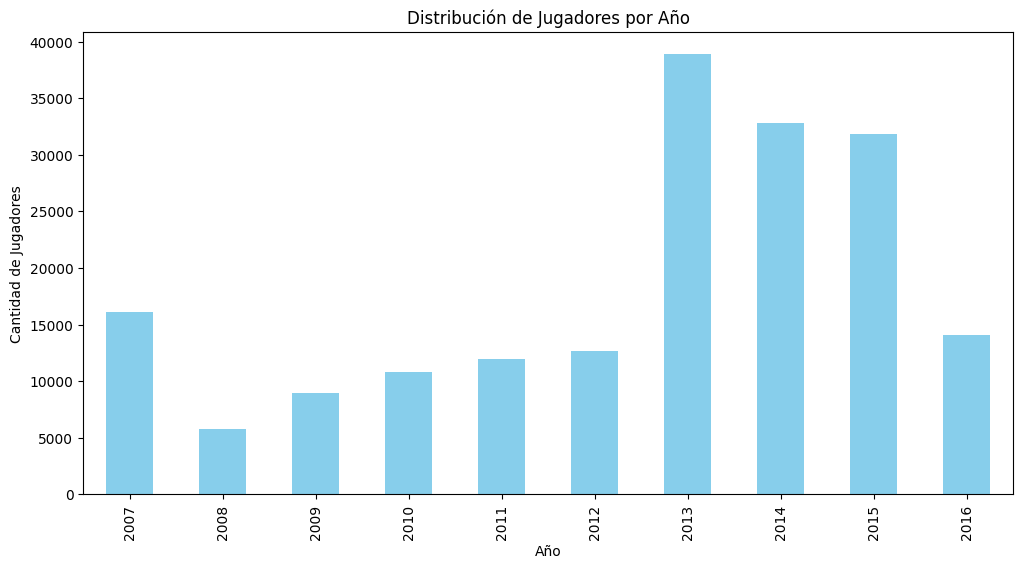

In [ ]:
# Agrupar jugadores por año.
players_per_year = df['Player_Attributes']['year'].value_counts().sort_index()

# Graficar la distribución
plt.figure(figsize=(12, 6))
players_per_year.plot(kind='bar', color='skyblue')
plt.title('Distribución de Jugadores por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Jugadores')
plt.show()

> en la siguiente distribucion podemos observar mas claramente el comprotamiento de la los talentos dutamte el cada año, y notamos como habiamos visualizando anteriormente que para el rango de fechas 2008-2009 hubo un descenso en cuanto a la cantidad de talentos para esa fecha, retomandose de manera significativa solo a partir del 2013.

### CalculandoUso "media, mediana, desviación estándar" usando la libreria Numpy.

In [ ]:
# Seleccionar solo las columnas numericas.
numeric_data = df['Player_Attributes'].select_dtypes(include=['number'])


In [ ]:
# iterar sobre las columnas numericas.
for column in numeric_data.columns:
    # Calcular los valores estadisticos con numpy.
    mean_value = np.mean(numeric_data[column])
    median_value = np.median(numeric_data[column])
    std_value = np.std(numeric_data[column])

    # Imprimir valores.
    print(f'column: {column}')
    print(f'mean: {mean_value}')
    print(f'median: {median_value}')
    print(f'std: {std_value}')
    print('------------------------------------------------------')

column: id
mean: 91989.5
median: 91989.5
std: 53109.87391169994
------------------------------------------------------
column: player_fifa_api_id
mean: 165671.52429094783
median: 183488.0
std: 53850.94841663332
------------------------------------------------------
column: player_api_id
mean: 135900.61732381047
median: 77741.0
std: 136927.46837825433
------------------------------------------------------
column: overall_rating
mean: 68.59728880627031
median: 69.0
std: 7.025220447395198
------------------------------------------------------
column: potential
mean: 73.46734935698834
median: 74.0
std: 6.578073067009076
------------------------------------------------------
column: crossing
mean: 55.145560882279405
median: 59.0
std: 17.224777578665964
------------------------------------------------------
column: finishing
mean: 49.8078357194882
median: 53.0
std: 19.069151069132595
------------------------------------------------------
column: heading_accuracy
mean: 57.31479850851732
media

> Podemos notar que las caracteristicas con mayor correlacion serian el dribling, el ball_control, short_passing. visio

> Se han impreso los valores de la media, mediana y el valor de la desviacion estandar de cada columna numerica en el bloque anterior usando la libreria de numpy en un bucle for iterando columna a columna para no repetir codigo, se puede escrolear el elemento y ver los valores de cada columna.

## Conclusiones.
> Debido a que no se contaba con un glosario adecuado para entender de mejor manera los datos registrados se ha decidido enfocar el analisis en la tabla 'Player_Attributes', manteniendo el foco en el prospecto y el comportamiento de los jugadores a traves del tiempo y su evolucion.
- Para las correlaciones entre los atributos y el rendimiento del jugador, tiene mayor relevancia las habilidades de control y reaccion que la fuerza y la velocidad.
- No existe diferencia significativa entre los jugadores diestros y zurdos ya que el uso de un pie u otro no parece inferir en el regate.
- La tendencia nos indica que los jugadores estan mejorando a lo largo del tiempo.
- Los jugadores tienen un alto nivel de crecimiento a lo largo de su carrera.
- existen picos de caidas en algunos años y otros parece mantener un patron, pero aunque no es muy significativo la tendencia se mantiene en una tendencia positiva.


## Modelo Predictivo